In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
print(f"Data Shape: {df.shape}")
df.info()

print(f"Number of duplicate rows: {df.duplicated().sum()}")

df.describe()

Data Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Number of duplicate rows: 0


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


/tmp/ipykernel_1522/297261750.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='Set2')


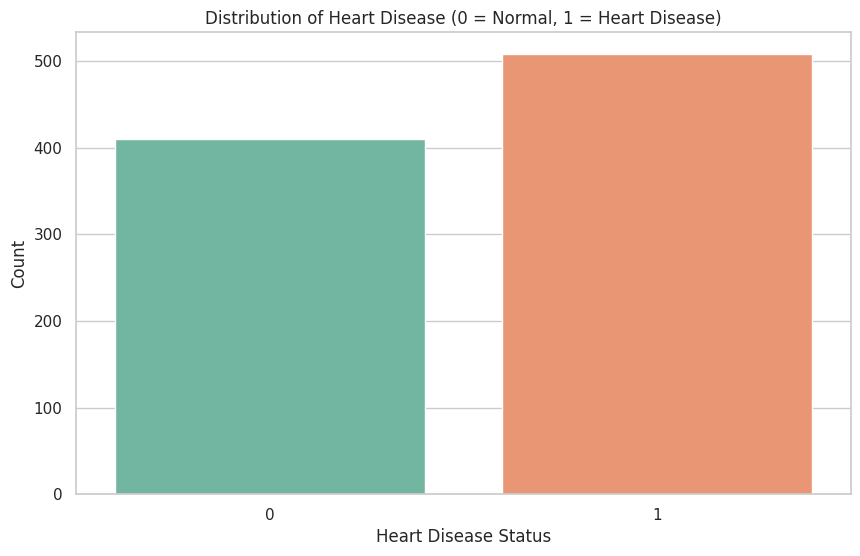

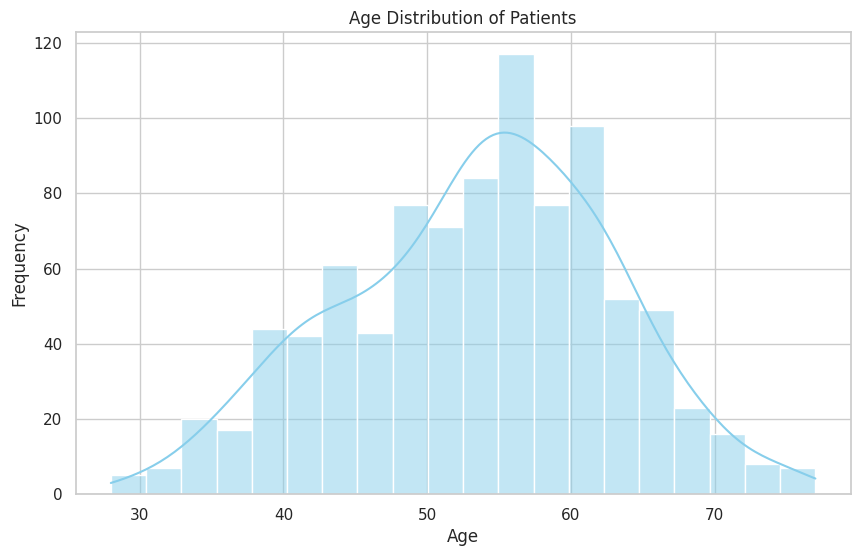

In [18]:
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Distribution of Heart Disease (0 = Normal, 1 = Heart Disease)')
plt.xlabel('Heart Disease Status')
plt.ylabel('Count')
plt.show()

sns.histplot(x='Age', data=df, kde=True, color='skyblue', bins=20)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1522/1987349588.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='Cholesterol', data=df, palette='Pastel1')


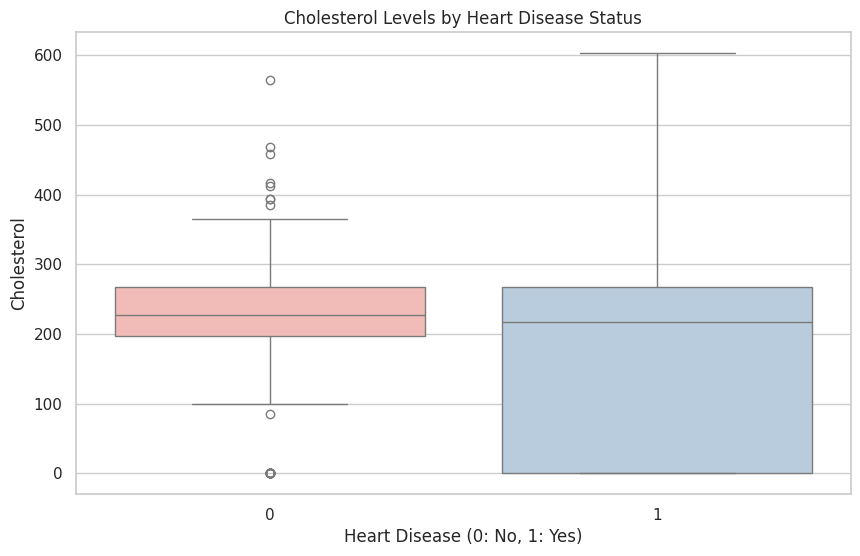

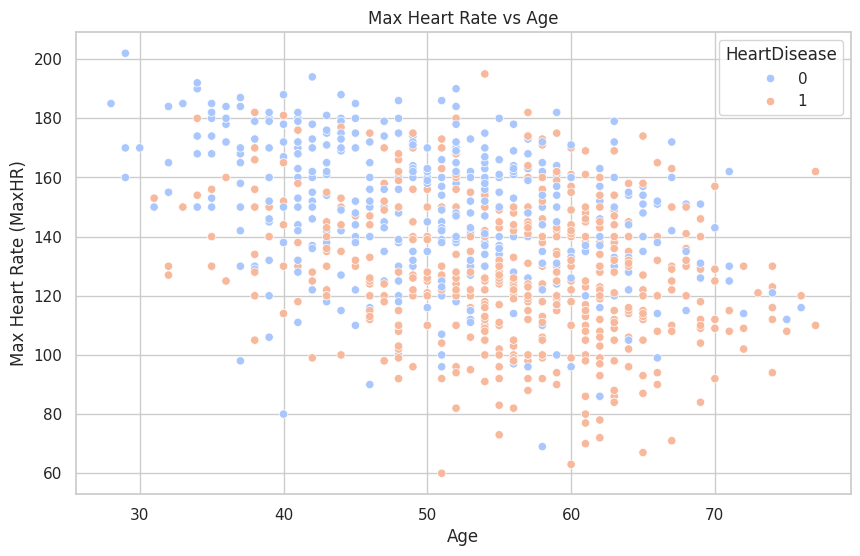

In [21]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df, palette='Pastel1')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Cholesterol')
plt.show()

sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=df, palette='coolwarm')
plt.title('Max Heart Rate vs Age')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (MaxHR)')
plt.show()


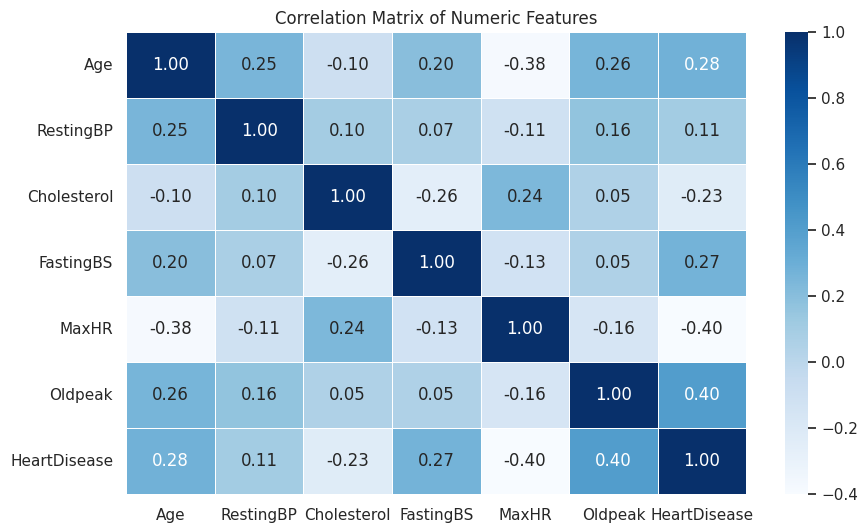

In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [26]:
# Impute illogical zero values in Cholesterol and RestingBP with the Median
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

print("Illogical zero values have been successfully handled.")

def categorize_bp(bp):
    if bp < 120:
        return 'Normal'
    elif 120 <= bp < 140:
        return 'Prehypertension'
    else:
        return 'Hypertension'

df['BP_Category'] = df['RestingBP'].apply(categorize_bp)

df[['RestingBP', 'BP_Category']].head()

Illogical zero values have been successfully handled.


,RestingBP,BP_Category
0,140,Hypertension
1,160,Hypertension
2,130,Prehypertension
3,138,Prehypertension
4,150,Hypertension


In [29]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('HeartDisease')

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    joblib.dump(le, f'{col}_encoder.pkl')

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
joblib.dump(scaler, 'scaler.pkl')

print("Data preprocessing completed and transformers saved successfully!")

Data preprocessing completed and transformers saved successfully!


In [32]:
correlations = df.corr()['HeartDisease'].abs().sort_values(ascending=False)
print("Correlation of features with HeartDisease:")
print(correlations)

selected_features = correlations[correlations > 0.1].index.drop('HeartDisease').tolist()

print(f"\nSelected features after filtering ({len(selected_features)} features):")
print(selected_features)

X = X[selected_features]

Correlation of features with HeartDisease:
HeartDisease      1.000000
ST_Slope          0.558771
ExerciseAngina    0.494282
Oldpeak           0.403951
MaxHR             0.400421
ChestPainType     0.386828
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.117798
BP_Category       0.113135
RestingECG        0.057384
Cholesterol       0.042988
Name: HeartDisease, dtype: float64

Selected features after filtering (10 features):
['ST_Slope', 'ExerciseAngina', 'Oldpeak', 'MaxHR', 'ChestPainType', 'Sex', 'Age', 'FastingBS', 'RestingBP', 'BP_Category']


# Core Concepts in Model Building:
1- The Importance of Validation:

Splitting the data into training (Train) and testing (Test) sets helps evaluate the model's ability to generalize to new, unseen data. This process protects the model from Overfitting.

2- Hyperparameter Tuning:

This is the process of searching for the optimal external configurations of the model (parameters that the model cannot learn directly from the data) to maximize predictive accuracy and overall performance efficiency.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 734
Testing set size: 184


In [36]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
    print("-" * 30)

=== Logistic Regression ===
Accuracy:  0.85
Precision: 0.85
Recall:    0.89
------------------------------
=== Random Forest ===
Accuracy:  0.87
Precision: 0.88
Recall:    0.88
------------------------------
=== Support Vector Machine ===
Accuracy:  0.86
Precision: 0.85
Recall:    0.90
------------------------------


In [38]:
from sklearn.model_selection import GridSearchCV
import joblib

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Hyperparameters found:")
print(grid_search.best_params_)

final_preds = best_model.predict(X_test)
print("\nFinal Classification Report for the deployed model:")
print(classification_report(y_test, final_preds))

joblib.dump(best_model, 'heart_disease_model.pkl')
print("Final model saved successfully as 'heart_disease_model.pkl'!")

Best Hyperparameters found:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 150}

Final Classification Report for the deployed model:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

Final model saved successfully as 'heart_disease_model.pkl'!
